In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

27172
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]

xc: -0.5
init. cond.:   0.20   0.20   0.20 




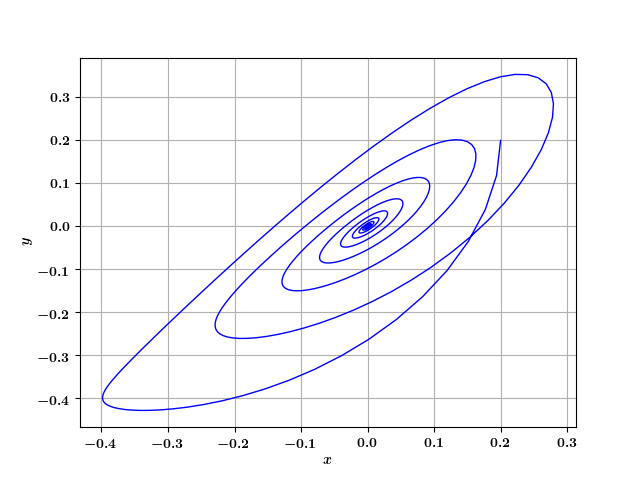

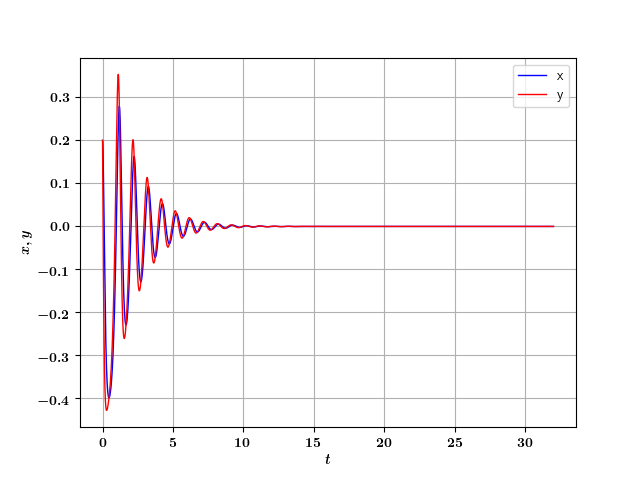

In [4]:
# ---------------------------------------------------------------
# --- Prepare the system ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 3  # the number of degrees of freedom
    Nx2 = Nx**2 - 1
    Nx3 = Nx**3 - 1

    F_terms = [None] * (N_nl + 1)
    for ii_nl in range(N_nl + 1):
        F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

    # --- Lorentz attractor ---
    # rr < 1:            one fixed point (0,0,0):    a single stable point
    # 1 < rr < 24.74:    three fixed points: two stable symmetric points and one unstable
    # rr > 24.74: chaos: three fixed points: three unstable points
    # two symmetric points: (+- np.sqrt(bb*(rr-1.)), +- np.sqrt(bb*(rr-1.)), rr - 1)
    # ---
    # rescaling factors: just for reference:
    # scale_x = np.sqrt(cx*bb*(rr-1.))
    # scale_y = np.sqrt(cy*bb*(rr-1.))
    # scale_z = cz*(rr - 1.)

    # ----------------------------------------------------
    # --- Lorentz attractor (strange attractor) ---
    if sel_case == 0:
        # tmax, nt = 40, 12
        # tmax, nt = 4, 9
        # tmax, nt = 8, 10
        tmax, nt = 16, 11

        # ss, rr, bb = 10., 28., 8./3.
        # ss, rr, bb = 4, 28., 8./3.
        # ss, rr, bb = 10., 24.74, 8./3.

        # F = [
        #     lambda x: ss * (x[1] - x[0] ),
        #     lambda x: x[0]  * (rr - x[2]) - x[1],
        #     lambda x: x[0] *x[1]  - bb*x[2] 
        # ]

        # ss, rr, bb = 10., 28., 8./3.
        # cx, cy, cz = 8., 16., 2.

        # ss, rr, bb = 10., 0.5, 8./3.
        # cx, cy, cz = 8., 16., 2.

        # ss, rr, bb = 10., 0.5, 8./3.  # -> works
        # cx, cy, cz = 1., 1., 1.  

        ss, rr, bb = 10., 2.0, 8./3. # -> # ubstable
        cx, cy, cz = 1., 1., 1.
        x_init = np.array([0.8, 0.0, 0.0])

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        F = [
            lambda x: a0 * x[0] + a1 * x[1],
            lambda x: b0 * x[0] + b1 * x[1] + b02 * x[0] * x[2],
            lambda x: c2 * x[2] + c01 * x[0] * x[1]
        ]

        # F = [
        #     lambda x: ss * (np.sqrt(cy/cx) * x[1] - x[0]),
        #     lambda x: np.sqrt(cx/cy) * x[0]  * (rr*(1. - cz*x[2]) + cz*x[2]) - x[1],
        #     lambda x: np.sqrt(cx*cy)/cz*bb*x[0]*x[1]  - bb*x[2] 
        # ]

        # --- Construct system matrices ---
 
        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1] = b0, b1
        F_terms[1][2,2] = c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

    # ----------------------------------------------------
    # --- Lorentz attractor (strange attractor, modified) ---
    if sel_case == 1:
        tmax, nt = 4, 9

        ss, rr, bb = 10., 0.5, 8./3.  # -> works
        cx, cy, cz = 1., 1., 1. 
        x_init = np.array([0.8, 0.0, 0.0])

        # ss, rr, bb = 10., 28.0, 8./3.  # -> 
        # cx, cy, cz = 1., 1., 1.

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        xc0 = 0.6
        F = [
            lambda x: a0 * (x[0] - xc0) + a1 * x[1],
            lambda x: b0 * (x[0] - xc0)  + b1 * x[1] + b02 * (x[0] - xc0)  * x[2],
            lambda x: c2 * x[2] + c01 * (x[0] - xc0) * x[1]
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = - a0 * xc0
        F_terms[0][1,0] = - b0 * xc0

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2]  = b0, b1, - b02 * xc0
        F_terms[1][2,1], F_terms[1][2,2] = -c01 * xc0, c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

        # ------------------------------------------------
        # --- ref ---
        # F = [
        #     lambda x: a0 * x[0] + a1 * x[1],
        #     lambda x: b0 * x[0] + b1 * x[1] + b02 * x[0] * x[2],
        #     lambda x: c2 * x[2] + c01 * x[0] * x[1]
        # ]
        # # *** matrix F1 ***
        # F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        # F_terms[1][1,0], F_terms[1][1,1] = b0, b1
        # F_terms[1][2,2] = c2

        # # *** matrix F2 ***
        # F_terms[2][1,2] = b02
        # F_terms[2][2,1] = c01

    # ----------------------------------------------------
    # --- Lorentz attractor: one stable point ---
    if sel_case == 2:
        tmax, nt = 4, 9

        ss, rr, bb = 10., 0.5, 8./3.  # -> works
        cx, cy, cz = 1., 1., 1. 
        xc0 = 0.6
        x_init = np.array([0.8, 0.0, 0.0])

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        F = [
            lambda x: a0 * (x[0] - xc0) + a1 * x[1],
            lambda x: b0 * (x[0] - xc0)  + b1 * x[1] + b02 * (x[0] - xc0)  * x[2],
            lambda x: c2 * x[2] + c01 * (x[0] - xc0) * x[1]
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = - a0 * xc0
        F_terms[0][1,0] = - b0 * xc0

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2]  = b0, b1, - b02 * xc0
        F_terms[1][2,1], F_terms[1][2,2] = -c01 * xc0, c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

    # ----------------------------------------------------
    # --- Lorentz attractor: two stable points, one unstable ---
    if sel_case == 3:
        tmax, nt = 8, 10

        # ss, rr, bb = 10., 4.2, 8./3.  # -> works
        # cx, cy, cz = 1., 1., 1. 
        # xc0 = 0.0
        # x_init = np.array([-1.2, 0.0, 0.0])

        ss, rr, bb = 10., 4.2, 8./3.  # -> works
        cx, cy, cz = 2., 2., 2. 
        xc0 = -1.2
        x_init = np.array([0.0, 0.0, 0.0])

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        F = [
            lambda x: a0 * (x[0] - xc0) + a1 * x[1],
            lambda x: b0 * (x[0] - xc0)  + b1 * x[1] + b02 * (x[0] - xc0) * x[2],
            lambda x: c2 * x[2] + c01 * (x[0] - xc0) * x[1]
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = - a0 * xc0
        F_terms[0][1,0] = - b0 * xc0

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2]  = b0, b1, - b02 * xc0
        F_terms[1][2,1], F_terms[1][2,2] = -c01 * xc0, c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

    # ----------------------------------------------------------
    # --- Lorentz attractor: shifted center ---
    if sel_case == 4:
        tmax, nt = 32, 11

        ss, rr, bb = 10., 0.4, 8./3.  
        cx, cy, cz = 1., 1., 1. 

        # xc0, yc0, zc0 = 0.8, 0.6, 0.4
        # xc0, yc0, zc0 = 0.8, 0.0, 0.6

        xc0, yc0, zc0 = 0.0, 0.8, 0.0
        x_init = np.array([0.1, 0.2, 0.9])

        # xc0, yc0, zc0 = 0.0, 0.0, 0.8
        # x_init = np.array([0.1, 0.9, 0.2])

        a0, a1 = -ss, ss * np.sqrt(cy/cx)
        b0, b1 = np.sqrt(cx/cy) * rr, -1.
        b02 = np.sqrt(cx/cy) * cz * (-rr + 1)
        c01, c2 = np.sqrt(cx*cy)/cz*bb, -bb 
        F = [
            lambda x: a0 * (x[0] - xc0) + a1 * (x[1] - yc0),
            lambda x: b0 * (x[0] - xc0) + b1 * (x[1] - yc0) + b02 * (x[0] - xc0) * (x[2] - zc0),
            lambda x: c2 * (x[2] - zc0) + c01 * (x[0] - xc0) * (x[1] - yc0)
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = - a0 * xc0 - a1 * yc0
        F_terms[0][1,0] = - b0 * xc0 - b1 * yc0 + b02 * xc0 * zc0
        F_terms[0][2,0] = - c2 * zc0 + c01 * xc0 * yc0 

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = a0, a1
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2]  = b0 - b02 * zc0, b1, - b02 * xc0
        F_terms[1][2,0], F_terms[1][2,1], F_terms[1][2,2] = -c01 * yc0, -c01 * xc0, c2

        # *** matrix F2 ***
        F_terms[2][1,2] = b02
        F_terms[2][2,1] = c01

    # ----------------------------------------------------------
    # --- Lorentz attractor: shifted center: rechecked ---
    if sel_case == 5:
        tmax, nt = 32, 11

        # # --- a single stable point (problematic)  ---
        # ss, rr, bb = 10., 0.4, 8./3.  
        # cx, cz = 1., 1.
        # xc0, yc0, zc0 = 0.0, 0.8, 0.0
        # x_init = np.array([0.1, 0.2, 0.9])

        # # --- a single stable point (working)  ---
        # ss, rr, bb = 10., 0.4, 8./3.  
        # cx, cz = 1., 1.
        # xc0, yc0, zc0 = 0.8, 0.0, 0.4
        # x_init = np.array([0.1, 0.2, 0.9])

        # # --- OPT1: stable point in the case with three fixed points (working) ---
        # ss, rr, bb = 10., 2.4, 8./3.  
        # cx, cz = 2., 2. 
        # xc0, yc0, zc0 = -0.7, -0.7, -0.5
        # x_init = np.array([0.2, 0.2, 0.2])

        # --- OPT2: stable point in the case with three fixed points (worse) ---
        ss, rr, bb = 10., 10.4, 8./3.  
        cx, cz = 4., 4. 
        xc0, yc0, zc0 = -0.5, -0.5, -0.25
        x_init = np.array([0.2, 0.2, 0.2])

        # # --- OPT3: stable point in the case with three fixed points (worse) ---
        # ss, rr, bb = 10., 10.4, 8./3.  
        # cx, cz = 4., 4. 
        # xc0, yc0, zc0 = 0.5, 0.5, -0.25
        # x_init = np.array([0.2, 0.2, 0.20])

        # --- construct the system ---
        eta_x_2 = cx*bb*(rr - 1)
        eta_z = cz*(rr - 1)
        c02 = eta_x_2 / eta_z

        fx_x, fx_y, fx_0 = -ss, ss, ss * (xc0 - yc0)
        fy_xz, fy_x, fy_y, fy_z = - eta_z, rr + eta_z*zc0, -1, eta_z*xc0
        fy_0                    = yc0 - rr*xc0 - eta_z*xc0*zc0
        fz_xy, fz_x, fz_y, fz_z = c02, -c02*yc0, -c02*xc0, -bb 
        fz_0                    = bb*zc0 + c02*xc0*yc0
        F = [
            lambda x: fx_x * x[0] + fx_y * x[1] + fx_0,
            lambda x: fy_xz * x[0] * x[2] + fy_x * x[0] + fy_y * x[1] + fy_z * x[2] + fy_0,
            lambda x: fz_xy * x[0] * x[1] + fz_x * x[0] + fz_y * x[1] + fz_z * x[2] + fz_0
        ]

        # *** matrix F0 ***
        F_terms[0][0,0] = fx_0
        F_terms[0][1,0] = fy_0
        F_terms[0][2,0] = fz_0

        # *** matrix F1 ***
        F_terms[1][0,0], F_terms[1][0,1] = fx_x, fx_y
        F_terms[1][1,0], F_terms[1][1,1], F_terms[1][1,2] = fy_x, fy_y, fy_z
        F_terms[1][2,0], F_terms[1][2,1], F_terms[1][2,2] = fz_x, fz_y, fz_z

        # *** matrix F2 ***
        F_terms[2][1,2] = fy_xz
        F_terms[2][2,1] = fz_xy
        
    # ----------------------------------------------------
    print("xc: {:0.3}".format(xc0))
    return F, tmax, nt, F_terms, Nx, x_init
# ------------------------------------------------------------------------------
sel_case_ = 5

N_nl_orig_ = 2
F_, tmax_, nt_, F_terms_, Nx_, x_init_ref_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]


print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

In [5]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_

sol_emb_, t_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, F_terms_)

# sol_emb_, t_emb_ = ca.solve_carleman_global(x_init_ref_, N_nl, N_nl_orig_, t_, F_terms_)

Ntot: 1092




In [29]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
from scipy.integrate import RK45
import random
mix.reload_module(mix)
def solve_carleman(x_init, N_nl):
    # --------------------------------------------------------------
    # * x_init: initial conditions
    # * N_nl: the number of NL terms used for Carleman embedding 
    # * Remark: N_nl_orig_ is the highest (assumed) nonlinearity in 
    #           the original system of equations
    # --------------------------------------------------------------
    def f_to_RK(t, x):
        f_eqs = np.dot(A, x) + B
        return f_eqs
    # --------------------------------------------------------------
    def form_block(jj_sideband, i_nl):
        jj_sideband = int(jj_sideband)
        Nr, Nc = Nx_**(i_nl+1), Nx_**(i_nl + 1 + jj_sideband)
        term_sum = np.zeros((Nr, Nc))

        # print("***")
        # print(term_sum.shape)
        for ii_sum in range(i_nl+1):
            one_left  = eyes_list[ii_sum]
            one_right = eyes_list[i_nl - ii_sum]
            temp_prod = np.kron(
                one_left, 
                np.kron(F_terms_[1 + jj_sideband], one_right)
            )
            # print()
            # print("ii_sum = {:d}".format(ii_sum))
            # print(one_left.shape)
            # print(F_terms_[1 + jj_sideband].shape)
            # print(one_right.shape)
            # print(temp_prod.shape)
            term_sum += temp_prod
        return term_sum
    # --------------------------------------------------------------

    # --- The number of elements for each next nonlinear term in embedding ---
    N_terms = np.zeros(N_nl, dtype=int)
    N_tot = 0
    for ii in range(N_nl):
        N_terms[ii] = int(Nx_**(ii+1))
        N_tot += N_terms[ii]
    print("Ntot: {:d}".format(N_tot))

    # --- Form the system: d_t u = A u + B ---
    # *** prepare unit matrices ***
    eyes_list = [None] * N_nl
    for ii in range(N_nl):
        eyes_list[ii] = np.eye(int(Nx_**ii))

    # *** matrix B ***
    B = np.zeros(N_tot)
    B[:N_terms[0]] = F_terms_[0][:,0]

    # *** matrix A ***
    A = np.zeros((N_tot, N_tot))
    i_start_r = 0
    for i_nl in range(N_nl):  # -> consider N_nl rows with blocks where
            # the i_nl-th row contains (non-square) matrices with 
            # the number of rows = N_terms[i_nl];
            # -> correspondingly, the submatrix at ir-th block-row and ic-th block-column has
            # N_terms[ir] rows and N_terms[ic] columns;
        N_loc = N_terms[i_nl]
        i_end_r = i_start_r + N_loc

        # print("\n-------------")
        # print("i_nl, irs, ire: {:d}; {:d}, {:d}".format(i_nl, i_start_r, i_end_r))
 
        # *** diagonal blocks ***
        i_start_c = i_start_r
        i_end_c   = i_end_r
        A[i_start_r:i_end_r, i_start_c:i_end_c] = form_block(0, i_nl)
        del i_start_c, i_end_c

        # *** left-sideband blocks ***
        if i_nl > 0:
            i_start_c = i_start_r - N_terms[i_nl - 1]
            i_end_c   = i_start_c + N_terms[i_nl - 1]
            A[i_start_r:i_end_r, i_start_c:i_end_c] = form_block(-1, i_nl)
            del i_start_c, i_end_c

        # *** blocks in several right sidebands ***  
        i_start_c = i_start_r
        i_end_c = None
        for jj in range(N_nl_orig_ - 1): # consider (N_nl_orig - 1) right sidebands
            jj_sb = jj + 1
            # print("\n>>> jj_sb = {:d}".format(jj_sb))
            if i_nl < (N_nl - jj_sb): # the block-rows near the righ-hand side of the matrix does not 
                        # include one or several right sidebands
                i_start_c += N_terms[i_nl + jj]
                i_end_c   = i_start_c + N_terms[i_nl + jj_sb]
                A[i_start_r:i_end_r, i_start_c:i_end_c] = form_block(jj_sb, i_nl)
        del i_start_c, i_end_c

        # *** shift the starting row ***
        i_start_r += N_loc
    del i_start_r, i_end_r

    # --- Prepare initial conditions ---
    xs_init = np.zeros(N_tot)
    prod = 1.
    i_start = 0
    for i_nl in range(N_nl):
        i_end = i_start + N_terms[i_nl]

        # print()
        # print("{:d}: {:d}, {:d}, {:d}".format(i_nl, i_start, N_terms[i_nl], i_end))

        # *** i_nl-th Kronecker product ***
        prod = np.kron(x_init, prod)

        # *** set the initial conditions for the terms of the i_nl-th Carleman term ***
        xs_init[i_start:i_end] = prod[:]
        i_start = i_end
    del i_start, i_end, prod

    # --- Runge-Kutta solver ---
    oo = RK45(
        f_to_RK,
        t_[0], 
        xs_init, 
        t_[-1], first_step=dt_, max_step=dt_
    )
    sol_carleman      = np.zeros((Nt_, N_tot))
    sol_carleman[0,:] = xs_init
    Nt_act = 1

    oo.step()
    oo.t
    while mix.compare_two_strings(oo.status, "running"):
        oo.step()
        Nt_act += 1
        if Nt_act - 1 == Nt_:
            print(oo.t)
        sol_carleman[Nt_act-1,:] = oo.y.copy()
    return sol_carleman
# -----------------------------------------------------------------------
N_nl = 6   # should be >= N_nl_orig_
sol_carleman_ = solve_carleman(x_init_ref_, N_nl)

Ntot: 1092


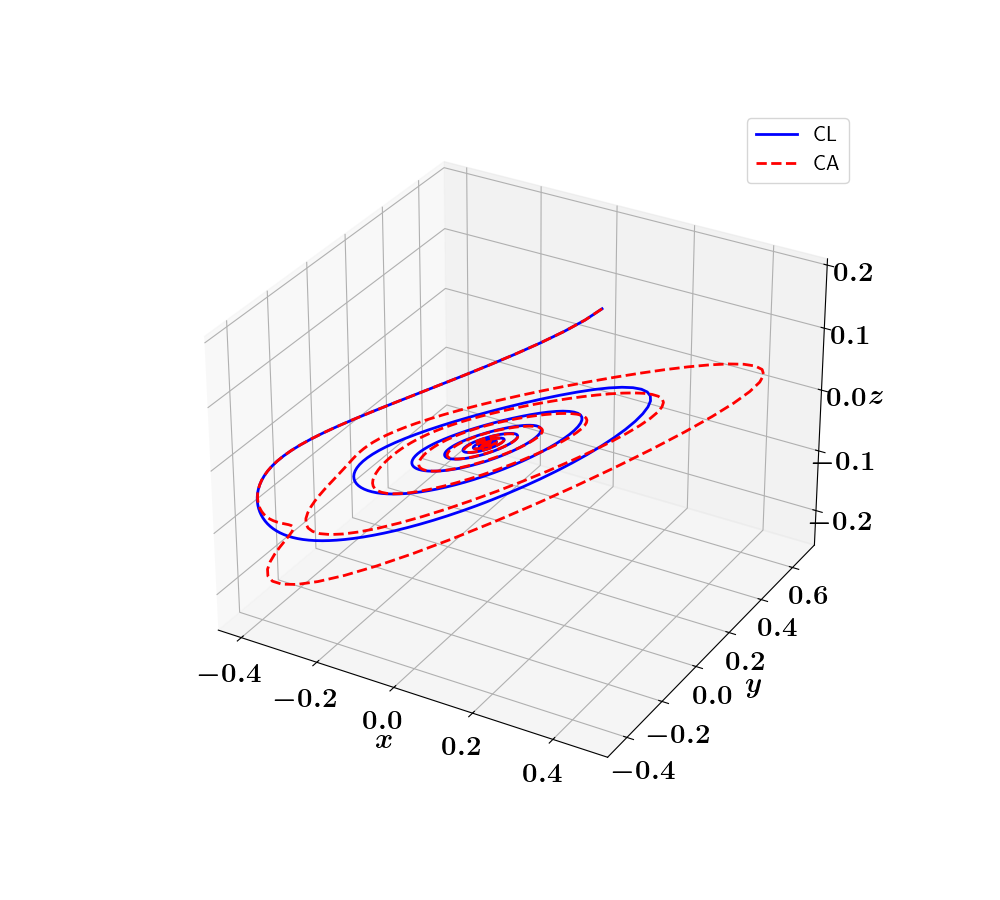

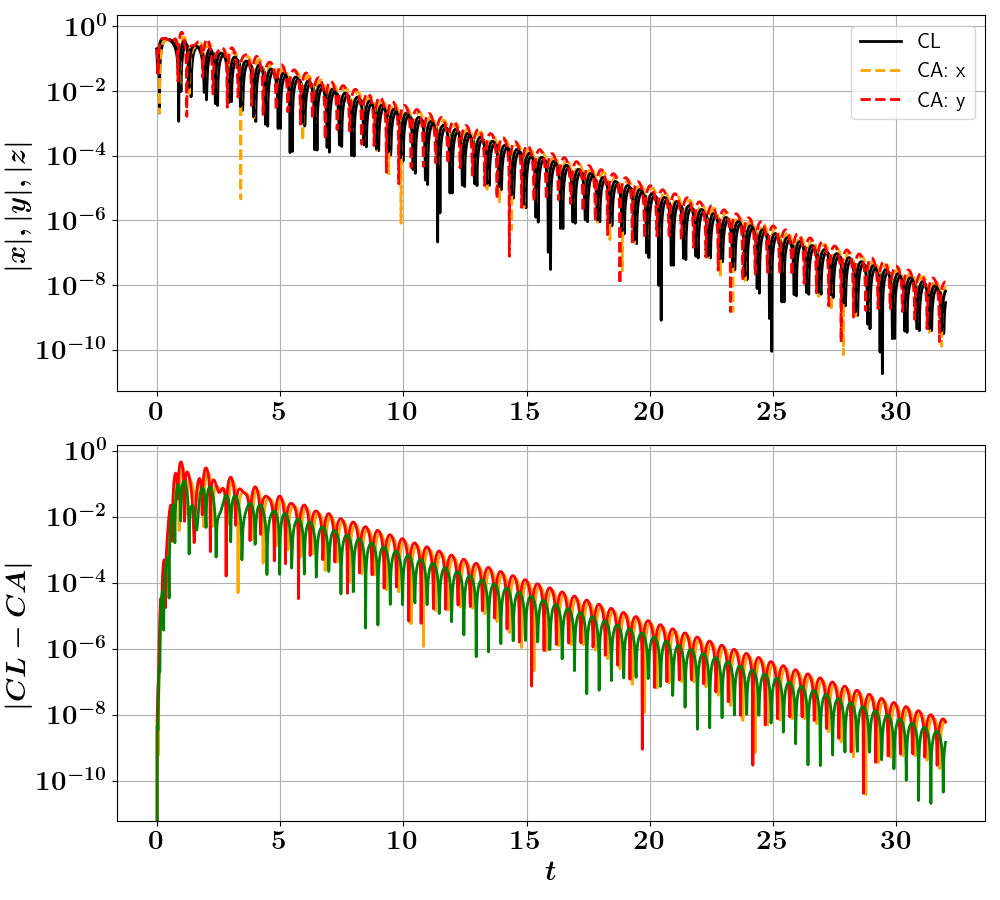

In [6]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(t_ref_, sol_ref_, t_emb_, sol_emb_)